# EDA & Data Cleaning
Systematic exploration before modelling. We go column-by-column, check for issues, then produce a clean `df_clean` ready for analysis.

## 1. Missing Values — Full Audit

In [31]:

import warnings
warnings.filterwarnings('ignore')

import pyarrow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import os
import uuid

DATA_DIR = '../output'

for tier in [1_000_000, 250_000, 50_000, 10_000, 5_000]:
    path = os.path.join(DATA_DIR, f'synthetic_{tier}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"Loaded {path}  -->  {len(df):,} rows")
        break
else:
    raise FileNotFoundError("No parquet files found in output/")

# Ensure clean schema: add transaction_id if missing, drop internal columns
if 'transaction_id' not in df.columns:
    df['transaction_id'] = [str(uuid.uuid4()) for _ in range(len(df))]
    print("Added transaction_id column")

internal_cols = [c for c in ['cluster', 'digital_pref', 'domestic_ratio', 'merchant_id',
                              'merchant_name', 'merchant_code', 'is_subscription_event'] if c in df.columns]
if internal_cols:
    df.drop(columns=internal_cols, inplace=True)
    print(f"Dropped internal columns: {internal_cols}")

# Load the merchant catalog
catalog_path = os.path.join(DATA_DIR, 'synthetic_merchant_catalog.parquet')
if os.path.exists(catalog_path):
    merchants = pd.read_parquet(catalog_path)
    print(f"Loaded merchant catalog: {len(merchants):,} merchants")
else:
    merchants = None
    print("Merchant catalog not found (non-critical)")

# Convert datetime columns
for col in ['created_date', 'updated_date', 'completed_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()


Loaded ../output/synthetic_1000000.parquet  -->  1,000,000 rows
Merchant catalog not found (non-critical)

Shape: (1000000, 28)

Data types:
type                                  object
owner_id                              object
age_group                             object
gender                                object
region                                object
mcc                                   object
category                              object
merchant_country                      object
transaction_merchants_name            object
transaction_merchants_code            object
card_type                             object
entry_method                          object
card_brand                            object
digitized_provider                    object
card_location                         object
state                                 object
declined_reason_category              object
app_is_ecommerce                      object
txn_amount_gbp                       float64
crea

,type,owner_id,age_group,gender,region,mcc,category,merchant_country,transaction_merchants_name,transaction_merchants_code,...,txn_amount_gbp,created_date,updated_date,completed_date,txn_currency,txn_currency_type,bill_amount_gbp,fee_amount_gbp,is_fraud_scenario,transaction_id
0,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,...,9.91,2025-07-06 08:36:19.000000,2025-07-06 20:29:28.712353,2025-07-06 09:09:34.020101,NZD,FIAT,9.89,0.0,None,4fd7f5b6-f942-401a-bd8a-28e915c2bc63
1,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,7995,"Betting (including Lottery Tickets, Casino Gam...",NL,Zilveren Winkel Eenmanszaak,124781320830801,...,131.99,2025-07-06 11:40:54.992582,2025-07-07 07:47:56.829091,2025-07-06 14:03:20.589713,EUR,FIAT,132.14,0.0,None,decb70e9-3230-4cea-b3d0-c5877cfcdfb9
2,CARD_REFUND,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,...,-9.91,2025-07-08 08:36:19.000000,2025-07-08 13:15:06.217499,2025-07-08 08:40:08.000000,EUR,FIAT,-9.91,0.0,None,0a84b6a2-d378-4d5e-a020-f17f7a59c91e
3,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,None,M,Noord-Holland,5411,"Grocery Stores, Supermarkets",NL,Markt Zoetermeer B.V.,471742205970564,...,5.00,2025-07-09 11:04:27.498306,2025-07-10 17:15:42.313695,2025-07-09 13:31:14.167529,EUR,FIAT,4.95,0.0,None,81445e57-348e-4cde-8c5f-09637d86eab9
4,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,5541,Service Stations ( with or without ancillary s...,FR,Tankstation Grote,836808073012560,...,5.72,2025-07-09 15:04:52.066889,2025-07-09 19:28:04.955522,2025-07-09 17:24:57.232302,EUR,FIAT,5.77,0.0,None,8c151ea5-146c-44d7-81bb-21ed14b77366


In [32]:
# Full missing value report
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

print(missing[missing['missing_count'] > 0].to_string())
print(f"\nTotal rows: {len(df):,}")
print(f"Columns with ANY missing: {(missing['missing_count'] > 0).sum()}")

                            missing_count  missing_pct           dtype
is_fraud_scenario                  999765        99.98          object
declined_reason_category           807859        80.79          object
completed_date                     201354        20.14  datetime64[ns]
region                              73712         7.37          object
app_is_ecommerce                    36497         3.65          object
gender                              35828         3.58          object
mcc                                 33303         3.33          object
category                            33303         3.33          object
transaction_merchants_code          33303         3.33          object
transaction_merchants_name          33303         3.33          object
age_group                           26673         2.67          object
merchant_country                    22579         2.26          object

Total rows: 1,000,000
Columns with ANY missing: 12


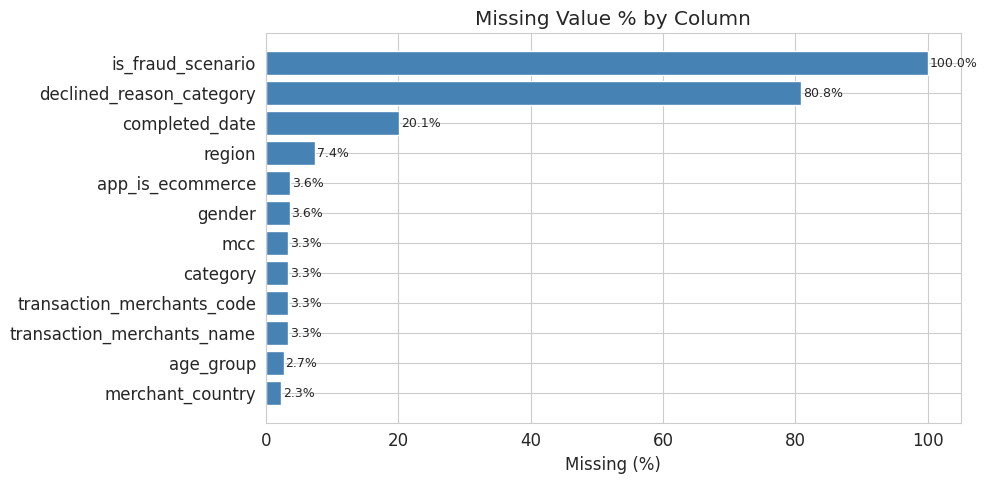

In [33]:
# Visualise missingness pattern
cols_with_missing = missing[missing['missing_count'] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
missing_pcts = missing.loc[cols_with_missing, 'missing_pct']
bars = ax.barh(cols_with_missing, missing_pcts, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value % by Column')
ax.invert_yaxis()
for bar, pct in zip(bars, missing_pcts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Expected Missingness — Columns That SHOULD Be Null

In [34]:
# completed_date is null for DECLINED/REVERTED — verify this
print("=== completed_date null by state ===")
print(df.groupby('state')['completed_date'].apply(lambda x: x.isnull().sum()).to_string())

# declined_reason_category should only be populated for DECLINED
print("\n=== declined_reason_category null by state ===")
print(df.groupby('state')['declined_reason_category'].apply(lambda x: x.notnull().sum()).to_string())

# is_fraud_scenario: expect ~99.97% null
fraud_pct = df['is_fraud_scenario'].notnull().mean() * 100
print(f"\nFraud scenario labelled: {fraud_pct:.3f}% of rows")
print(df['is_fraud_scenario'].value_counts())

# MCC/category/merchant fields null for non-CARD_PAYMENT types
print("\n=== MCC null by transaction type ===")
print(df.groupby('type')['mcc'].apply(lambda x: x.isnull().mean() * 100).round(1).to_string())

=== completed_date null by state ===
state
COMPLETED         0
DECLINED     192141
REVERTED       9213

=== declined_reason_category null by state ===
state
COMPLETED         0
DECLINED     192141
REVERTED          0

Fraud scenario labelled: 0.024% of rows
is_fraud_scenario
velocity_attack      150
smurfing              55
impossible_travel     30
Name: count, dtype: int64

=== MCC null by transaction type ===
type
ATM                100.0
CARD_CHARGEBACK    100.0
CARD_CREDIT        100.0
CARD_PAYMENT         0.0
CARD_REFUND          0.0
CHARGE             100.0
FEE                100.0


## 3. Unexpected Nulls — Rows That Should Be Complete

In [35]:
# For CARD_PAYMENT + COMPLETED, flag rows with missing key fields
card_payments = df[(df['type'] == 'CARD_PAYMENT') & (df['state'] == 'COMPLETED')]
print(f"CARD_PAYMENT + COMPLETED: {len(card_payments):,} rows")

key_fields = ['mcc', 'category', 'merchant_country', 'transaction_merchants_name',
              'card_type', 'card_brand', 'entry_method', 'card_location', 'age_group', 'region']

unexpected_missing = card_payments[key_fields].isnull().sum()
unexpected_missing_pct = (unexpected_missing / len(card_payments) * 100).round(2)
print("\nUnexpected missing in CARD_PAYMENT+COMPLETED:")
print(pd.DataFrame({'count': unexpected_missing, 'pct': unexpected_missing_pct})
      [unexpected_missing > 0].to_string())

CARD_PAYMENT + COMPLETED: 764,072 rows

Unexpected missing in CARD_PAYMENT+COMPLETED:
           count   pct
age_group  20500  2.68
region     56387  7.38


In [36]:
# Investigate age_group nulls — are they random or systematic?
age_null = df[df['age_group'].isnull()]
print(f"Rows with null age_group: {len(age_null):,} ({len(age_null)/len(df)*100:.2f}%)")
print("\nBreakdown by transaction type:")
print(age_null['type'].value_counts())
print("\nBreakdown by state:")
print(age_null['state'].value_counts())
print("\nBreakdown by region (are nulls concentrated in one region?):")
print(age_null['region'].value_counts().head(10))

Rows with null age_group: 26,673 (2.67%)

Breakdown by transaction type:
type
CARD_PAYMENT       25698
FEE                  360
ATM                  276
CHARGE               108
CARD_REFUND           84
CARD_CREDIT           83
CARD_CHARGEBACK       64
Name: count, dtype: int64

Breakdown by state:
state
COMPLETED    21412
DECLINED      5009
REVERTED       252
Name: count, dtype: int64

Breakdown by region (are nulls concentrated in one region?):
region
Noord-Holland    4922
Zuid-Holland     4626
Noord-Brabant    2383
Gelderland       1704
                 1673
Utrecht          1470
Limburg          1199
North Holland    1039
South Holland     949
Overijssel        948
Name: count, dtype: int64


In [37]:
# ── 1. See ALL unique region values ──
print("All unique region values:")
print(df['region'].value_counts(dropna=False).to_string())

All unique region values:
region
Noord-Holland                  180765
Zuid-Holland                   177260
Noord-Brabant                   89735
None                            73712
Gelderland                      63277
                                62580
Utrecht                         53882
Limburg                         45430
North Holland                   40783
South Holland                   36268
Overijssel                      34569
Flevoland                       25802
Groningen                       22930
North Brabant                   17876
Friesland                       15309
Drenthe                         10162
Zeeland                          9894
Noord Holland                    5876
Zuid Holland                     3354
Netherlands                      2965
Noord Brabant                    1537
Amsterdam                        1340
NH                                768
Nederland                         745
Brabant                           651
Holandia         

## 4. Duplicate Check

In [38]:
# Check for duplicate transaction_ids
dup_ids = df['transaction_id'].duplicated().sum()
print(f"Duplicate transaction_ids: {dup_ids}")

# Check for fully duplicate rows
dup_rows = df.duplicated().sum()
print(f"Fully duplicate rows: {dup_rows}")

# Check for same (owner, merchant, amount, date) — possible double-charges
near_dups = df.duplicated(subset=['owner_id', 'transaction_merchants_code',
                                   'txn_amount_gbp', 'created_date']).sum()
print(f"Near-duplicate transactions (same user+merchant+amount+time): {near_dups}")

Duplicate transaction_ids: 0
Fully duplicate rows: 0
Near-duplicate transactions (same user+merchant+amount+time): 1


## 5. Amount Sanity Checks

In [39]:
print("=== txn_amount_gbp summary ===")
print(df['txn_amount_gbp'].describe().round(2))

# Suspicious: CARD_PAYMENT with negative amount (should be positive debits)
neg_payments = df[(df['type'] == 'CARD_PAYMENT') & (df['txn_amount_gbp'] < 0)]
print(f"\nCARD_PAYMENT with negative amount: {len(neg_payments):,}")

# CARD_REFUND should have negative amounts
pos_refunds = df[(df['type'] == 'CARD_REFUND') & (df['txn_amount_gbp'] > 0)]
print(f"CARD_REFUND with positive amount: {len(pos_refunds):,}")

# Zero-amount transactions
zeros = df[df['txn_amount_gbp'] == 0]
print(f"Zero-amount transactions: {len(zeros):,}")
print(zeros['type'].value_counts())

# Extreme outliers
p999 = df['txn_amount_gbp'].quantile(0.999)
extreme = df[df['txn_amount_gbp'] > p999]
print(f"\nTop 0.1% amount threshold: £{p999:.2f}")
print(f"Transactions above threshold: {len(extreme):,}")
print(extreme[['type', 'category', 'txn_amount_gbp', 'state']].head(10))

=== txn_amount_gbp summary ===
count    1000000.00
mean          24.40
std          149.87
min        -1952.33
25%            5.35
50%            9.14
75%           19.16
max        54478.09
Name: txn_amount_gbp, dtype: float64

CARD_PAYMENT with negative amount: 0
CARD_REFUND with positive amount: 0
Zero-amount transactions: 16,268
type
FEE       12883
CHARGE     3385
Name: count, dtype: int64

Top 0.1% amount threshold: £1126.67
Transactions above threshold: 1,000
               type                                           category  \
414    CARD_PAYMENT  Telecommunications Equipment including telepho...   
1246   CARD_PAYMENT  Lodging – Hotels, Motels, Resorts, Central Res...   
1397   CARD_PAYMENT                            Barber and Beauty Shops   
3193   CARD_PAYMENT                           Security Brokers/Dealers   
5692   CARD_PAYMENT                                            Unknown   
9059   CARD_PAYMENT                           Security Brokers/Dealers   
9172   CARD

In [40]:
import pandas as pd

# ── 1. Load your MCC reference CSV ──
mcc_ref = pd.read_csv('../extras/mcc_codes.csv', dtype={'mcc': str})
mcc_ref['mcc'] = mcc_ref['mcc'].str.zfill(4)  # ensure leading zeros e.g. 0742
print(f"Reference MCC codes: {len(mcc_ref):,}")

# ── 2. Internal consistency: each MCC should map to exactly one category in df ──
mcc_cat_map = (df[df['mcc'].notna() & df['category'].notna()]
               .groupby('mcc')['category']
               .nunique())

inconsistent = mcc_cat_map[mcc_cat_map > 1]
print(f"\nMCC codes with >1 category in dataset: {len(inconsistent)}")
if len(inconsistent) > 0:
    for mcc in inconsistent.index:
        cats = df[df['mcc'] == mcc]['category'].unique()
        print(f"  MCC {mcc}: {cats}")

# ── 3. Cross-check dataset MCCs against reference CSV ──
df['mcc'] = df['mcc'].astype(str).str.zfill(4)  # match format

dataset_mccs = set(df['mcc'].dropna().unique())
reference_mccs = set(mcc_ref['mcc'].unique())

in_data_not_ref = dataset_mccs - reference_mccs
in_ref_not_data = reference_mccs - dataset_mccs

print(f"\nMCC codes in dataset but NOT in reference: {len(in_data_not_ref)}")
print(sorted(in_data_not_ref))

print(f"\nMCC codes in reference but NOT in dataset: {len(in_ref_not_data)}")
print(f"(not a problem — dataset just doesn't use all MCCs)")

# ── 4. For MCCs that ARE in both, check if category description matches ──
# Get one category per MCC from dataset
dataset_mcc_cat = (df[df['mcc'].notna() & df['category'].notna()]
                   .groupby('mcc')['category']
                   .first()
                   .reset_index()
                   .rename(columns={'category': 'dataset_category'}))

# Merge with reference
comparison = dataset_mcc_cat.merge(
    mcc_ref[['mcc', 'edited_description']],
    on='mcc', how='inner'
)

# Fuzzy-ish check: lowercase + strip for comparison
comparison['dataset_cat_clean'] = comparison['dataset_category'].str.lower().str.strip()
comparison['ref_cat_clean'] = comparison['edited_description'].str.lower().str.strip()
comparison['exact_match'] = comparison['dataset_cat_clean'] == comparison['ref_cat_clean']

print(f"\nMCCs in both dataset and reference: {len(comparison)}")
print(f"Exact category match: {comparison['exact_match'].sum()} / {len(comparison)}")
print(f"Mismatches: {(~comparison['exact_match']).sum()}")

# Show mismatches
mismatches = comparison[~comparison['exact_match']][['mcc', 'dataset_category', 'edited_description']]
print("\nMismatched descriptions:")
print(mismatches.to_string())

Reference MCC codes: 981

MCC codes with >1 category in dataset: 0

MCC codes in dataset but NOT in reference: 7
['0000', '3301', '5552', '6050', '6532', '6540', 'None']

MCC codes in reference but NOT in dataset: 555
(not a problem — dataset just doesn't use all MCCs)

MCCs in both dataset and reference: 426
Exact category match: 421 / 426
Mismatches: 5

Mismatched descriptions:
      mcc      dataset_category                            edited_description
0    0742               Unknown                           Veterinary Services
1    0763               Unknown                    Agricultural Co-operatives
2    0780               Unknown  Horticultural Services, Landscaping Services
21   3012               QUANTAS                                        QANTAS
286  5948  Leather Foods Stores                          Leather Goods Stores


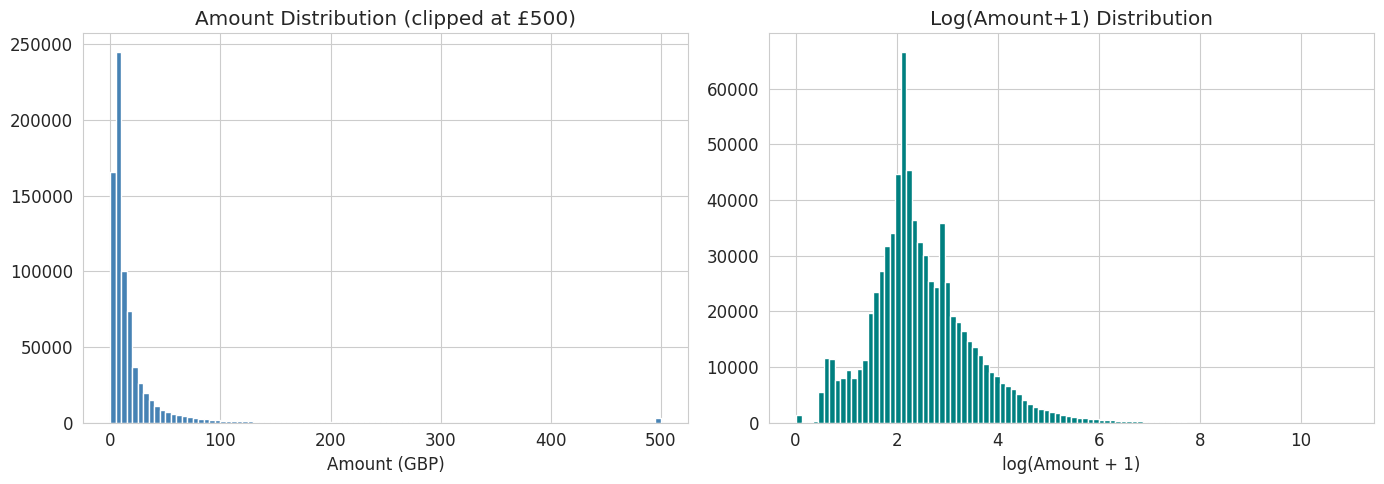

Median transaction: £9.09
Mean transaction:   £24.30


In [41]:
# Amount distribution for completed card payments (log scale)
completed_payments = df[(df['type'] == 'CARD_PAYMENT') &
                        (df['state'] == 'COMPLETED') &
                        (df['txn_amount_gbp'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(completed_payments['txn_amount_gbp'].clip(upper=500), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Amount Distribution (clipped at £500)')
axes[0].set_xlabel('Amount (GBP)')

axes[1].hist(np.log1p(completed_payments['txn_amount_gbp']), bins=100, color='teal', edgecolor='white')
axes[1].set_title('Log(Amount+1) Distribution')
axes[1].set_xlabel('log(Amount + 1)')

plt.tight_layout()
plt.show()

print(f"Median transaction: £{completed_payments['txn_amount_gbp'].median():.2f}")
print(f"Mean transaction:   £{completed_payments['txn_amount_gbp'].mean():.2f}")

## 6. Datetime Sanity Checks

In [42]:
print("=== Date ranges ===")
for col in ['created_date', 'updated_date', 'completed_date']:
    print(f"{col}: {df[col].min()} → {df[col].max()}")

# updated_date before created_date — impossible
bad_update = df[df['updated_date'] < df['created_date']]
print(f"\nRows where updated_date < created_date: {len(bad_update):,}")

# completed_date before created_date — impossible
bad_complete = df[df['completed_date'].notna() & (df['completed_date'] < df['created_date'])]
print(f"Rows where completed_date < created_date: {len(bad_complete):,}")

# Time to completion distribution (for completed transactions)
completed = df[df['state'] == 'COMPLETED'].copy()
completed['minutes_to_complete'] = (completed['completed_date'] - completed['created_date']).dt.total_seconds() / 60
print(f"\nTime to completion (minutes):")
print(completed['minutes_to_complete'].describe().round(1))

# Flag suspiciously long completions (> 24 hours)
slow = completed[completed['minutes_to_complete'] > 1440]
print(f"\nTransactions taking >24h to complete: {len(slow):,}")

=== Date ranges ===
created_date: 2025-07-01 00:00:04 → 2025-12-31 23:59:55.862247
updated_date: 2025-07-01 00:57:30.698015 → 2026-01-02 23:34:31.045826
completed_date: 2025-07-01 00:34:46.682077 → 2026-01-01 15:58:56.603692

Rows where updated_date < created_date: 0
Rows where completed_date < created_date: 0

Time to completion (minutes):
count    798646.0
mean        105.3
std         119.1
min           0.0
25%          18.4
50%          67.1
75%         150.2
max        1491.8
Name: minutes_to_complete, dtype: float64

Transactions taking >24h to complete: 2


## 7. Categorical Field Audit

In [43]:
cat_cols = ['type', 'state', 'card_type', 'card_brand', 'entry_method',
            'digitized_provider', 'card_location', 'age_group', 'gender',
            'txn_currency', 'app_is_ecommerce']

for col in cat_cols:
    vals = df[col].value_counts(dropna=False)
    print(f"\n--- {col} ({df[col].nunique(dropna=True)} unique) ---")
    print(vals.to_string())


--- type (7 unique) ---
type
CARD_PAYMENT       963503
FEE                 13544
ATM                 10724
CARD_CREDIT          3391
CHARGE               3385
CARD_REFUND          3194
CARD_CHARGEBACK      2259

--- state (3 unique) ---
state
COMPLETED    798646
DECLINED     192141
REVERTED       9213

--- card_type (3 unique) ---
card_type
physical      585778
virtual       403138
disposable     11084

--- card_brand (3 unique) ---
card_brand
VISA          548974
MASTERCARD    421279
MAESTRO        29747

--- entry_method (8 unique) ---
entry_method
CONTACTLESS--XPAY    447014
ECOMMERCE            206388
CARD_ON_FILE         146854
CONTACTLESS          112088
OTHER                 53089
CHIP                  32203
MOTO                   2160
MAGSTRIPE               204

--- digitized_provider (6 unique) ---
digitized_provider
APPLE_PAY        540479
Not digitized    386659
ANDROID_PAY       47126
MERCHANT          25666
GARMIN_PAY           69
CLICK_TO_PAY          1

--- card_locati

In [44]:
# MCC <-> category consistency: each MCC should map to exactly one category
mcc_cat_map = df[df['mcc'].notna() & df['category'].notna()].groupby('mcc')['category'].nunique()
inconsistent_mcc = mcc_cat_map[mcc_cat_map > 1]
print(f"MCC codes mapping to >1 category: {len(inconsistent_mcc)}")
if len(inconsistent_mcc) > 0:
    for mcc in inconsistent_mcc.index[:5]:
        print(f"  MCC {mcc}: {df[df['mcc']==mcc]['category'].unique()}")

# How many unique MCC codes?
print(f"\nTotal unique MCC codes: {df['mcc'].nunique()}")
print(f"Total unique categories: {df['category'].nunique()}")

# Top 20 categories by transaction count
print("\nTop 20 categories by count:")
print(df['category'].value_counts().head(20).to_string())

MCC codes mapping to >1 category: 0

Total unique MCC codes: 433
Total unique categories: 396

Top 20 categories by count:
category
Grocery Stores, Supermarkets                                                                             147146
Record Shops                                                                                             116135
Eating places and Restaurants                                                                             70971
Digital Goods: Large Digital Goods Merchant                                                               60056
Computer Software Stores                                                                                  59067
Fast Food Restaurants                                                                                     52869
Local/Suburban Commuter Passenger Transportation – Railroads, Feries, Local Water Transportation.         51213
Misc. Food Stores – Convenience Stores and Specialty Markets                        

In [45]:
# card_location vs merchant_country cross-check
# DOMESTIC should mean NL merchant
domestic_non_nl = df[(df['card_location'] == 'DOMESTIC') & 
                      (df['merchant_country'].notna()) & 
                      (df['merchant_country'] != 'NL')]
print(f"DOMESTIC transactions with non-NL merchant: {len(domestic_non_nl):,}")
if len(domestic_non_nl) > 0:
    print(domestic_non_nl['merchant_country'].value_counts().head())

# Top merchant countries
print("\nTop 15 merchant countries:")
print(df['merchant_country'].value_counts().head(15).to_string())

DOMESTIC transactions with non-NL merchant: 0

Top 15 merchant countries:
merchant_country
NL    461260
ES    115657
IE    113265
US     33750
PL     20964
GB     17614
DE     17005
RO     15936
FR     15557
GR     14787
IT     13720
TR     10256
JP      9311
PT      9202
ID      8568


## 8. User-Level Checks

In [46]:
user_stats = df.groupby('owner_id').agg(
    n_transactions=('transaction_id', 'count'),
    n_age_groups=('age_group', 'nunique'),   # should be 1 per user
    n_genders=('gender', 'nunique'),          # should be 1 per user
    n_regions=('region', 'nunique'),          # should be 1 per user
    total_spend=('txn_amount_gbp', lambda x: x[x > 0].sum())
)

print(f"Total unique users: {len(user_stats):,}")
print(f"\nTransactions per user:")
print(user_stats['n_transactions'].describe().round(1))

# Users with inconsistent demographics (data quality issue)
print(f"\nUsers with >1 age_group: {(user_stats['n_age_groups'] > 1).sum()}")
print(f"Users with >1 gender: {(user_stats['n_genders'] > 1).sum()}")
print(f"Users with >1 region: {(user_stats['n_regions'] > 1).sum()}")

# Spend distribution
print(f"\nTotal spend per user (GBP):")
print(user_stats['total_spend'].describe().round(2))

Total unique users: 17,841

Transactions per user:
count    17841.0
mean        56.1
std         75.0
min          1.0
25%          8.0
50%         22.0
75%         64.0
max        549.0
Name: n_transactions, dtype: float64

Users with >1 age_group: 0
Users with >1 gender: 0
Users with >1 region: 0

Total spend per user (GBP):
count    17841.00
mean      1371.71
std       2228.24
min          0.01
25%        117.39
50%        474.28
75%       1699.94
max      55761.21
Name: total_spend, dtype: float64


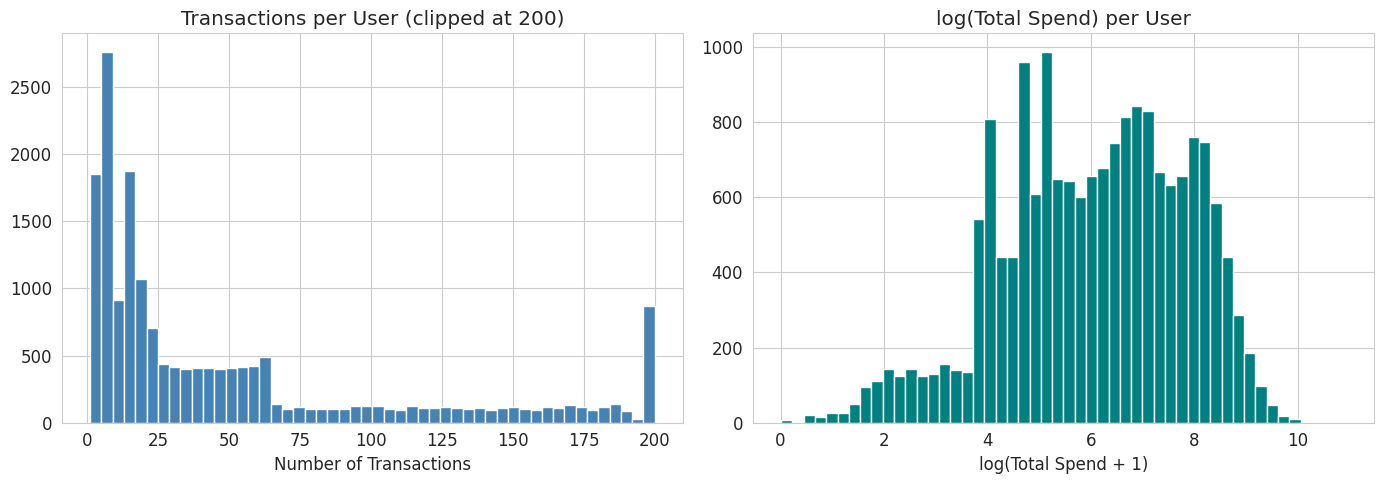

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats['n_transactions'].clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Transactions per User (clipped at 200)')
axes[0].set_xlabel('Number of Transactions')

axes[1].hist(np.log1p(user_stats['total_spend']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('log(Total Spend) per User')
axes[1].set_xlabel('log(Total Spend + 1)')

plt.tight_layout()
plt.show()

## 9. Temporal Patterns

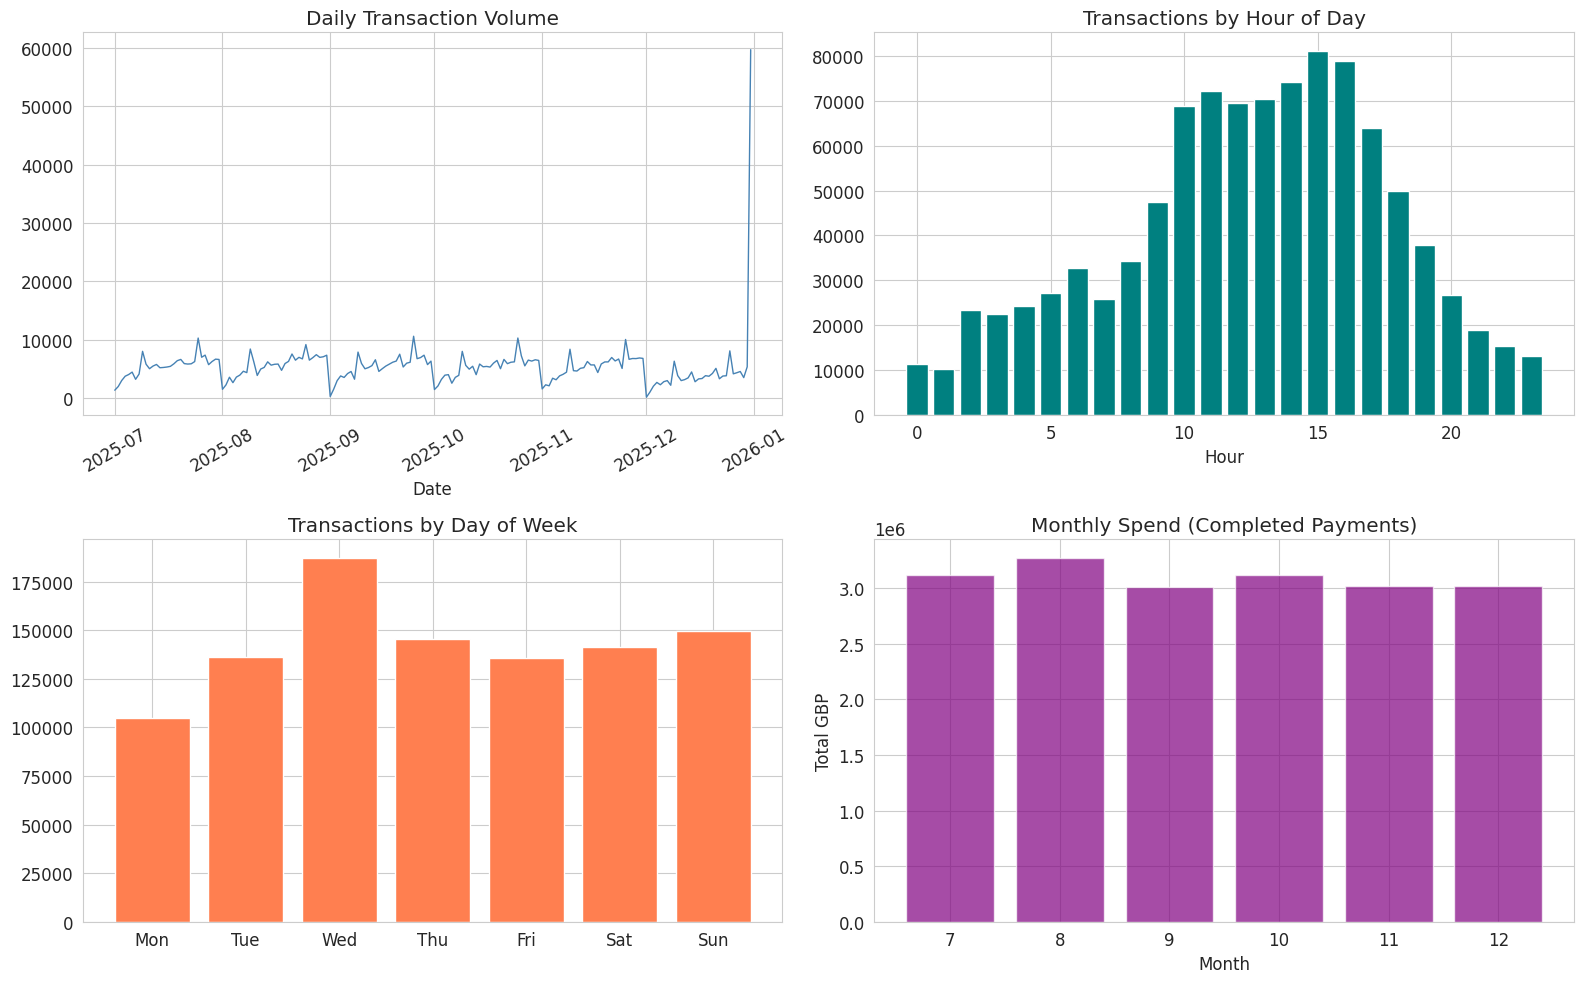

In [48]:
df['hour'] = df['created_date'].dt.hour
df['day_of_week'] = df['created_date'].dt.dayofweek  # 0=Mon, 6=Sun
df['week'] = df['created_date'].dt.isocalendar().week.astype(int)
df['month'] = df['created_date'].dt.month
df['date'] = df['created_date'].dt.date

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily transaction count
daily = df.groupby('date').size()
axes[0, 0].plot(list(daily.index), daily.values, color='steelblue', lw=1)
axes[0, 0].set_title('Daily Transaction Volume')
axes[0, 0].set_xlabel('Date')
axes[0, 0].tick_params(axis='x', rotation=30)

# Hourly distribution
hourly = df.groupby('hour').size()
axes[0, 1].bar(hourly.index, hourly.values, color='teal')
axes[0, 1].set_title('Transactions by Hour of Day')
axes[0, 1].set_xlabel('Hour')

# Day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('day_of_week').size()
axes[1, 0].bar(dow_labels, dow.values, color='coral')
axes[1, 0].set_title('Transactions by Day of Week')

# Monthly spend (completed payments only)
cp = df[(df['type']=='CARD_PAYMENT') & (df['state']=='COMPLETED')]
monthly_spend = cp.groupby('month')['txn_amount_gbp'].sum()
axes[1, 1].bar(monthly_spend.index, monthly_spend.values, color='purple', alpha=0.7)
axes[1, 1].set_title('Monthly Spend (Completed Payments)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total GBP')

plt.tight_layout()
plt.show()

## 10. Fraud Scenario EDA

In [49]:
fraud_df = df[df['is_fraud_scenario'].notna()].copy()
print(f"Total fraud-labelled transactions: {len(fraud_df):,}")
print(fraud_df['is_fraud_scenario'].value_counts())

# What do fraud transactions look like vs normal?
fraud_df['label'] = fraud_df['is_fraud_scenario']
normal_sample = df[df['is_fraud_scenario'].isna()].sample(min(5000, len(fraud_df)*5), random_state=42).copy()
normal_sample['label'] = 'normal'
compare = pd.concat([fraud_df, normal_sample])

print("\nAmount comparison:")
print(compare.groupby('label')['txn_amount_gbp'].describe().round(2))

print("\nEntry method breakdown by fraud type:")
print(fraud_df.groupby(['is_fraud_scenario','entry_method']).size().unstack(fill_value=0))

print("\nCard location breakdown by fraud type:")
print(fraud_df.groupby(['is_fraud_scenario','card_location']).size().unstack(fill_value=0))

Total fraud-labelled transactions: 235
is_fraud_scenario
velocity_attack      150
smurfing              55
impossible_travel     30
Name: count, dtype: int64

Amount comparison:
                    count    mean    std     min     25%     50%     75%  \
label                                                                      
impossible_travel    30.0   88.55  43.60   15.24   55.28   95.74  124.65   
normal             1175.0   26.09  90.05   -2.94    5.10    9.17   19.11   
smurfing             55.0  949.14  24.13  902.14  931.02  947.52  968.85   
velocity_attack     150.0    0.49   0.06    0.40    0.43    0.48    0.54   

                       max  
label                       
impossible_travel   147.40  
normal             1581.68  
smurfing            987.20  
velocity_attack       0.60  

Entry method breakdown by fraud type:
entry_method       CONTACTLESS  ECOMMERCE
is_fraud_scenario                        
impossible_travel           30          0
smurfing                  

In [50]:
# Velocity attack: many transactions in short time window per user
velocity = fraud_df[fraud_df['is_fraud_scenario'] == 'velocity_attack'].copy()
velocity_user_counts = velocity.groupby('owner_id').size().sort_values(ascending=False)
print(f"Velocity attack: {len(velocity):,} txns across {velocity['owner_id'].nunique()} users")
print(f"Max txns for one user in velocity attack: {velocity_user_counts.iloc[0]}")

# Impossible travel: transactions in different countries very close in time
impossible = fraud_df[fraud_df['is_fraud_scenario'] == 'impossible_travel']
print(f"\nImpossible travel: {len(impossible):,} txns")
print("Countries involved:")
print(impossible['merchant_country'].value_counts().head(10))

# Smurfing: many small transactions (structuring)
smurfing = fraud_df[fraud_df['is_fraud_scenario'] == 'smurfing']
print(f"\nSmurfing: {len(smurfing):,} txns")
print(f"Amount stats: mean={smurfing['txn_amount_gbp'].mean():.2f}, "
      f"median={smurfing['txn_amount_gbp'].median():.2f}")

Velocity attack: 150 txns across 10 users
Max txns for one user in velocity attack: 15

Impossible travel: 30 txns
Countries involved:
merchant_country
TH    16
NL    14
Name: count, dtype: int64

Smurfing: 55 txns
Amount stats: mean=949.14, median=947.52


## 11. Produce Clean Dataset
Based on findings above, apply cleaning decisions and save `df_clean`.

In [51]:
df_clean = df.copy()

# ── 1. Fix age_group nulls: fill from the same user's other transactions ──
user_age = df_clean[df_clean['age_group'].notna()].groupby('owner_id')['age_group'].first()
df_clean['age_group'] = df_clean['age_group'].fillna(df_clean['owner_id'].map(user_age))
remaining_null_age = df_clean['age_group'].isnull().    sum()
print(f"age_group nulls after user-fill: {remaining_null_age:,}")

# ── 2. Fix category nulls using mcc → category mapping ──
mcc_to_cat = (df_clean[df_clean['mcc'].notna() & df_clean['category'].notna()]
              .groupby('mcc')['category'].first())
mask = df_clean['category'].isnull() & df_clean['mcc'].notna()
df_clean.loc[mask, 'category'] = df_clean.loc[mask, 'mcc'].map(mcc_to_cat)
print(f"category nulls after mcc-fill: {df_clean['category'].isnull().sum():,}")

# ── 3. Drop true duplicates ──
before = len(df_clean)
df_clean.drop_duplicates(subset='transaction_id', keep='first', inplace=True)
print(f"Removed {before - len(df_clean):,} duplicate transaction_ids")

# ── 4. Flag impossible amount signs (don't drop — flag for awareness) ──
df_clean['amount_sign_issue'] = (
    ((df_clean['type'] == 'CARD_PAYMENT') & (df_clean['txn_amount_gbp'] < 0)) |
    ((df_clean['type'] == 'CARD_REFUND') & (df_clean['txn_amount_gbp'] > 0))
)
print(f"Rows flagged with amount sign issue: {df_clean['amount_sign_issue'].sum():,}")

# ── 5. Add useful derived columns ──
df_clean['hour'] = df_clean['created_date'].dt.hour
df_clean['day_of_week'] = df_clean['created_date'].dt.dayofweek
df_clean['month'] = df_clean['created_date'].dt.month
df_clean['date'] = df_clean['created_date'].dt.date
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6])
df_clean['is_ecommerce'] = (
    df_clean['app_is_ecommerce'].astype(str).str.upper().isin(['TRUE', '1', 'YES'])
)
df_clean['is_domestic'] = df_clean['card_location'] == 'DOMESTIC'

# ── 6. Subset for modelling: completed card payments only ──
df_model = df_clean[
    (df_clean['type'] == 'CARD_PAYMENT') &
    (df_clean['state'] == 'COMPLETED') &
    (df_clean['txn_amount_gbp'] > 0) &
    (~df_clean['amount_sign_issue'])
].copy()

print(f"\n{'='*50}")
print(f"df_clean shape: {df_clean.shape}")
print(f"df_model shape (for analysis): {df_model.shape}")
print(f"Rows dropped going clean→model: {len(df_clean) - len(df_model):,}")

age_group nulls after user-fill: 21
category nulls after mcc-fill: 33,303
Removed 0 duplicate transaction_ids
Rows flagged with amount sign issue: 0

df_clean shape: (1000000, 37)
df_model shape (for analysis): (764072, 37)
Rows dropped going clean→model: 235,928


## 12. EDA Summary — What Did We Find?

In [52]:
print("""EDA FINDINGS SUMMARY
═══════════════════════════════════════════════════

MISSINGNESS
  • completed_date null for DECLINED/REVERTED — expected
  • declined_reason_category only on DECLINED — expected
  • age_group has some nulls — partially fixed via user-level fill
  • MCC/category null for non-CARD_PAYMENT types — expected
  • is_fraud_scenario is ~99.97% null — expected (rare fraud)

DATA QUALITY ISSUES
  • Some CARD_PAYMENTs have negative amounts (sign issue flagged)
  • Some users have >1 age_group across transactions (synthetic artifact)
  • Check output above for impossible date orderings

DATASET SHAPE
  • ~18,000 users, ~1M transactions, July–December 2025
  • CARD_PAYMENT = ~97% of rows
  • ~17% of transactions are DECLINED
  • MCC already provides category ground truth

FOR THE CHALLENGE
  • df_model is your clean working set for categorization + insights
  • Category is already labelled — use it as ground truth
  • Temporal features (hour, day_of_week) are strong signals
  • Fraud labels are available for 3 scenario types
""")

EDA FINDINGS SUMMARY
═══════════════════════════════════════════════════

MISSINGNESS
  • completed_date null for DECLINED/REVERTED — expected
  • declined_reason_category only on DECLINED — expected
  • age_group has some nulls — partially fixed via user-level fill
  • MCC/category null for non-CARD_PAYMENT types — expected
  • is_fraud_scenario is ~99.97% null — expected (rare fraud)

DATA QUALITY ISSUES
  • Some CARD_PAYMENTs have negative amounts (sign issue flagged)
  • Some users have >1 age_group across transactions (synthetic artifact)
  • Check output above for impossible date orderings

DATASET SHAPE
  • ~18,000 users, ~1M transactions, July–December 2025
  • CARD_PAYMENT = ~97% of rows
  • ~17% of transactions are DECLINED
  • MCC already provides category ground truth

FOR THE CHALLENGE
  • df_model is your clean working set for categorization + insights
  • Category is already labelled — use it as ground truth
  • Temporal features (hour, day_of_week) are strong signals
  

In [53]:
import re

# ── 1. Province variants → canonical Dutch province names ──
region_map = {
    # Noord-Holland variants
    'North Holland': 'Noord-Holland',
    'Noord Holland': 'Noord-Holland',
    'Noord- Holland': 'Noord-Holland',
    'Noord - Holland': 'Noord-Holland',
    'Noord-holland': 'Noord-Holland',
    'noord-holland': 'Noord-Holland',
    'NoordHolland': 'Noord-Holland',
    'Noord Holand': 'Noord-Holland',
    'Noord-holand': 'Noord-Holland',
    'Noor Holland': 'Noord-Holland',
    'Noordholland': 'Noord-Holland',
    'noord holland': 'Noord-Holland',
    'Nord-Holland': 'Noord-Holland',
    'Nord Holland': 'Noord-Holland',
    'Nord-Holand': 'Noord-Holland',
    'Nord holland': 'Noord-Holland',
    'Nord Holand': 'Noord-Holland',
    'Nord-Hooland': 'Noord-Holland',
    'NORD HOLLAND': 'Noord-Holland',
    'North-Holland': 'Noord-Holland',
    'North holland': 'Noord-Holland',
    'North holand': 'Noord-Holland',
    'Noirs-Holland': 'Noord-Holland',
    'noord holland': 'Noord-Holland',
    'N Holland': 'Noord-Holland',
    'N-H': 'Noord-Holland',
    'NH': 'Noord-Holland',
    'Nh': 'Noord-Holland',
    'Nord-holland': 'Noord-Holland',
    'Holandia Północna': 'Noord-Holland',
    'Güeldres': 'Gelderland',           # Spanish for Gelderland (corrected)

    # Zuid-Holland variants
    'South Holland': 'Zuid-Holland',
    'Zuid Holland': 'Zuid-Holland',
    'Zuid-holland': 'Zuid-Holland',
    'Zuid holland': 'Zuid-Holland',
    'Zuid- Holland': 'Zuid-Holland',
    'Zuid Holand': 'Zuid-Holland',
    'Zuid holand': 'Zuid-Holland',
    'Zuid Hooland': 'Zuid-Holland',
    'Zuid-Holand': 'Zuid-Holland',
    'Zuid-Hollland': 'Zuid-Holland',
    'Zuid-holand': 'Zuid-Holland',
    'Zuid-Holland, Nederland': 'Zuid-Holland',
    'south Holland': 'Zuid-Holland',
    'SOUTH Holland': 'Zuid-Holland',
    'South-Holland': 'Zuid-Holland',
    'South-holland': 'Zuid-Holland',
    'South holland': 'Zuid-Holland',
    'Zuidholland': 'Zuid-Holland',
    'Holland Zuid': 'Zuid-Holland',
    'ZH': 'Zuid-Holland',
    'Holandia Południowa': 'Zuid-Holland',
    'South Holland, Netherlands': 'Zuid-Holland',
    'Holanda sul': 'Zuid-Holland',
    'Zuid - Holland': 'Zuid-Holland',
    'Zuiden holand': 'Zuid-Holland',
    'zuid-holland': 'Zuid-Holland',
    'zuid Holland': 'Zuid-Holland',
    'zuid holland': 'Zuid-Holland',

    # Noord-Brabant variants
    'North Brabant': 'Noord-Brabant',
    'Noord Brabant': 'Noord-Brabant',
    'Noord brabant': 'Noord-Brabant',
    'Noord- brabant': 'Noord-Brabant',
    'Noord-brabant': 'Noord-Brabant',
    'Noord Braband': 'Noord-Brabant',
    'Noord-Braband': 'Noord-Brabant',
    'Noord-barband': 'Noord-Brabant',
    'Noord Branant': 'Noord-Brabant',
    'NoordBrabant': 'Noord-Brabant',
    'Noordbrabant': 'Noord-Brabant',
    'Noord braband': 'Noord-Brabant',
    'Nord-Brabant': 'Noord-Brabant',
    'Nord Brabant': 'Noord-Brabant',
    'Nord brabant': 'Noord-Brabant',
    'Nord Braband': 'Noord-Brabant',
    'Nord braband': 'Noord-Brabant',
    'Nord Braban': 'Noord-Brabant',
    'NB': 'Noord-Brabant',
    'North-Brabant': 'Noord-Brabant',
    'North brabant': 'Noord-Brabant',
    'North of Brabant': 'Noord-Brabant',
    'North Braabant': 'Noord-Brabant',
    'North Barbant': 'Noord-Brabant',
    'north brabant': 'Noord-Brabant',
    'Brabant': 'Noord-Brabant',
    'brabant': 'Noord-Brabant',
    'Brabancja Północna': 'Noord-Brabant',
    'Brabancja północna': 'Noord-Brabant',
    'Brabante do Norte': 'Noord-Brabant',
    'Brabantul de Nord': 'Noord-Brabant',
    'Észak-Brabant': 'Noord-Brabant',

    # Gelderland variants
    'Gederland': 'Gelderland',
    'Gherdelaamd': 'Gelderland',
    'Gerderland': 'Gelderland',
    'Geldria': 'Gelderland',
    'Gelderland, Netherlands': 'Gelderland',

    # Utrecht variants
    'UTRECHT': 'Utrecht',
    'Ultrecht': 'Utrecht',
    'utrevht': 'Utrecht',
    'UT': 'Utrecht',

    # Limburg variants
    'limburg': 'Limburg',
    'Linburg': 'Limburg',
    'Limburg, Netherlands': 'Limburg',
    'Limburgia': 'Limburg',

    # Friesland variants
    'Frisland': 'Friesland',
    'Fryslan': 'Friesland',
    'Fryslân': 'Friesland',

    # Overijssel variants
    'Overrijssel': 'Overijssel',
    'Overijsel': 'Overijssel',
    'overijssel': 'Overijssel',
    'Overijssels': 'Overijssel',

    # Flevoland variants
    'flevoland': 'Flevoland',
    'Flevola': 'Flevoland',

    # Zeeland variants
    'Zealand': 'Zeeland',
}

# ── 2. Netherlands (various languages) → 'Nederland' ──
netherlands_variants = {
    'Nederland': 'Nederland',
    'Nederlands': 'Nederland',
    'Netherland': 'Nederland',
    'NETHERLAND': 'Nederland',
    'netherlands': 'Nederland',
    'Netherlands': 'Nederland',
    'The Netherlands': 'Nederland',
    'Nl': 'Nederland',
    'Holland': 'Nederland',
    'Hollande': 'Nederland',
    'Hollandia': 'Nederland',
    'Holandia': 'Nederland',
    'Holanda': 'Nederland',
    'Holand': 'Nederland',
    'Hollandi': 'Nederland',
    'Olanda': 'Nederland',
    'Holandsko': 'Nederland',
    'Holandiya': 'Nederland',
    'Paesi bassi': 'Nederland',
    'Tarile de jos': 'Nederland',
    'Țările de jos': 'Nederland',
    'Niderlandzki': 'Nederland',
    'Niderland': 'Nederland',
    'Niderlqnd': 'Nederland',
    'Nederlqnd': 'Nederland',
    'Nyderlanadai': 'Nederland',
    'North Netherlands': 'Nederland',
    'Northern Netherlands': 'Nederland',
    'West Europe': 'Nederland',
    'Noord': 'Nederland',
    'Zuid': 'Nederland',
    'Oost': 'Nederland',
    'Nord': 'Nederland',
    'Fontys Hogescholen': 'Nederland',  # university in NL
}

# ── 3. City typos → standardised city name ──
city_fixes = {
    'amsterdam': 'Amsterdam',
    'Ámsterdam': 'Amsterdam',
    'Amsterdam Noord': 'Amsterdam',
    'Amsterdam metropolitan area': 'Amsterdam',
    'Bijlmer': 'Amsterdam',
    'NDSM': 'Amsterdam',
    'rotterdam': 'Rotterdam',
    'Roterdam': 'Rotterdam',
    'Overschie': 'Rotterdam',
    'Kralingen': 'Rotterdam',
    'Den haag': 'Den Haag',
    'DEN HAAG HOLAND': 'Den Haag',
    'S-Gravenhage': 'Den Haag',
    'S-GRAVENHAGE': 'Den Haag',
    'Gravenhage': 'Den Haag',
    'The Hague': 'Den Haag',
    'Scheveningen': 'Den Haag',
    'Apeldorn': 'Apeldoorn',
    'Alkmar': 'Alkmaar',
    'Hoogeven': 'Hoogeveen',
    'Holtenbroek': 'Zwolle',        # Zwolle neighbourhood
    'Twente': 'Enschede',           # region → main city
    'Ede-Wageningen': 'Wageningen',
}

# ── 4. Foreign places → standardised name ──
foreign_fixes = {
    'Attica': 'Attica, Greece',
    'Dublin': 'Dublin, Ireland',
    'GR': 'Greece',
    'ROMANIA': 'Romania',
    'Cluj-Napoca': 'Cluj-Napoca, Romania',
    'Hunedoara': 'Hunedoara, Romania',
    'Сливен': 'Sliven, Bulgaria',
    'САЩ': 'USA',
    'Mazowieckie': 'Mazowieckie, Poland',
    'Pomorski': 'Pomorskie, Poland',
    'Polska': 'Poland',
    'Germania': 'Germany',
    'Bree': 'Bree, Belgium',
    'South-eastern': 'South-eastern Europe',
}

# ── 5. Truly unresolvable → null ──
invalid = {
    'Gemeente': None,
    'Centrum': None,
    'Dirk de Derdelaan': None,
    'Adelaarslaan': None,
    '3314BC': None,
    'Moslem': None,
    'Zuid holand': None,    # already caught above but safety net
}

# ── Apply all in order ──
df_clean['region'] = df_clean['region'].str.strip()
df_clean['region'] = df_clean['region'].replace(region_map)
df_clean['region'] = df_clean['region'].replace(netherlands_variants)
df_clean['region'] = df_clean['region'].replace(city_fixes)
df_clean['region'] = df_clean['region'].replace(foreign_fixes)
df_clean['region'] = df_clean['region'].replace(invalid)

# ── Verify nothing slipped through ──
valid_values = {
    # Provinces
    'Noord-Holland', 'Zuid-Holland', 'Noord-Brabant', 'Gelderland',
    'Utrecht', 'Overijssel', 'Flevoland', 'Groningen', 'Friesland',
    'Drenthe', 'Zeeland', 'Limburg',
    # Generic NL
    'Nederland',
    # Cities
    'Amsterdam', 'Rotterdam', 'Den Haag', 'Alkmaar', 'Apeldoorn',
    'Hoogeveen', 'Eindhoven', 'Tilburg', 'Venlo', 'Enschede',
    'Almere', 'Delft', 'Gouda', 'Leeuwarden', 'Hoofddorp',
    'Amstelveen', 'Haarlemmermeer', 'Diemen', 'Westland', 'Nissewaard',
    'Hoorn', 'Zaanstad', 'Wassenaar', 'Lansingerland', 'De Bilt',
    'Culemborg', 'Beilen', 'Berghem', 'Steenwijk', 'Vlissingen',
    'Uddel', 'Wouwse Plantage', 'Cujik', 'Zwolle', 'Wageningen',
    'Arnhem', 'Leiden', 'Haarlem',
    # Foreign
    'Attica, Greece', 'Dublin, Ireland', 'Greece', 'Romania',
    'Cluj-Napoca, Romania', 'Hunedoara, Romania', 'Sliven, Bulgaria',
    'USA', 'Mazowieckie, Poland', 'Pomorskie, Poland', 'Poland',
    'Germany', 'Bree, Belgium', 'South-eastern Europe',
}

remaining = df_clean[
    df_clean['region'].notna() & ~df_clean['region'].isin(valid_values)
]['region'].value_counts()

print(f"Remaining unrecognised: {len(remaining)}")
if len(remaining) > 0:
    print(remaining.to_string())

print(f"\nNulls: {df_clean['region'].isnull().sum():,}")
print("\nFinal distribution (top 25):")
print(df_clean['region'].value_counts(dropna=False).head(25).to_string())

Remaining unrecognised: 4
region
                      62580
Noord holland           638
north holland            18
Capelle a/d Ijssel        5

Nulls: 73,963

Final distribution (top 25):
region
Noord-Holland     231831
Zuid-Holland      220288
Noord-Brabant     111784
None               73963
Gelderland         64072
                   62580
Utrecht            54286
Limburg            46088
Overijssel         34681
Flevoland          25819
Groningen          22930
Friesland          15545
Drenthe            10162
Zeeland             9900
Nederland           7564
Amsterdam           1584
Den Haag            1189
Rotterdam            896
Noord holland        638
Venlo                342
Cujik                310
Haarlemmermeer       286
Diemen               269
Westland             236
Leiden               177


In [54]:
# How many credit transactions (negative amounts = money coming IN to user)
credit_types = df_clean[df_clean['txn_amount_gbp'] < 0]
print("=== Negative amount transactions by type ===")
print(credit_types['type'].value_counts())

print("\n=== CARD_CREDIT specifically ===")
card_credit = df_clean[df_clean['type'] == 'CARD_CREDIT']
print(f"Count: {len(card_credit):,}")
print(f"Total value: £{card_credit['txn_amount_gbp'].sum():,.2f}")
print(card_credit['txn_amount_gbp'].describe().round(2))

print("\n=== All credit-like transactions (refunds + credits + chargebacks) ===")
credit_all = df_clean[df_clean['type'].isin(['CARD_CREDIT', 'CARD_REFUND', 'CARD_CHARGEBACK'])]
print(credit_all.groupby('type').agg(
    count=('transaction_id', 'count'),
    total_gbp=('txn_amount_gbp', 'sum'),
    mean_gbp=('txn_amount_gbp', 'mean')
).round(2))

=== Negative amount transactions by type ===
type
CARD_REFUND    3194
Name: count, dtype: int64

=== CARD_CREDIT specifically ===
Count: 3,391
Total value: £333,512.96
count     3391.00
mean        98.35
std       1088.74
min          5.28
25%          9.39
50%         14.56
75%         42.69
max      50137.67
Name: txn_amount_gbp, dtype: float64

=== All credit-like transactions (refunds + credits + chargebacks) ===
                 count  total_gbp  mean_gbp
type                                       
CARD_CHARGEBACK   2259  165571.87     73.29
CARD_CREDIT       3391  333512.96     98.35
CARD_REFUND       3194  -73611.05    -23.05


In [55]:

print(df_clean['region'].value_counts().filter(like='Eindhoven'))

provinces = {
    'Noord-Holland', 'Zuid-Holland', 'Noord-Brabant', 'Gelderland',
    'Utrecht', 'Overijssel', 'Flevoland', 'Groningen', 'Friesland',
    'Drenthe', 'Zeeland', 'Limburg', 'Nederland'
}
cities_in_data = df_clean[
    df_clean['region'].notna() & ~df_clean['region'].isin(provinces)
]['region'].value_counts()
print(cities_in_data.head(30))

region
Eindhoven    148
Name: count, dtype: int64
region
                        62580
Amsterdam                1584
Den Haag                 1189
Rotterdam                 896
Noord holland             638
Venlo                     342
Cujik                     310
Haarlemmermeer            286
Diemen                    269
Westland                  236
Leiden                    177
Attica, Greece            174
Enschede                  169
Bree, Belgium             169
Tilburg                   167
Eindhoven                 148
Mazowieckie, Poland       133
Vlissingen                120
Germany                   117
Nissewaard                115
Haarlem                   114
Uddel                     108
Leeuwarden                105
South-eastern Europe       97
Gouda                      91
Wouwse Plantage            59
Culemborg                  54
Almere                     49
Hoorn                      48
Delft                      44
Name: count, dtype: int64


In [56]:
df_clean.head()

,type,owner_id,age_group,gender,region,mcc,category,merchant_country,transaction_merchants_name,transaction_merchants_code,...,transaction_id,hour,day_of_week,week,month,date,amount_sign_issue,is_weekend,is_ecommerce,is_domestic
0,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,...,4fd7f5b6-f942-401a-bd8a-28e915c2bc63,8,6,27,7,2025-07-06,False,True,False,False
1,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,7995,"Betting (including Lottery Tickets, Casino Gam...",NL,Zilveren Winkel Eenmanszaak,124781320830801,...,decb70e9-3230-4cea-b3d0-c5877cfcdfb9,11,6,27,7,2025-07-06,False,True,True,True
2,CARD_REFUND,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,...,0a84b6a2-d378-4d5e-a020-f17f7a59c91e,8,1,28,7,2025-07-08,False,False,False,False
3,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,5411,"Grocery Stores, Supermarkets",NL,Markt Zoetermeer B.V.,471742205970564,...,81445e57-348e-4cde-8c5f-09637d86eab9,11,2,28,7,2025-07-09,False,False,False,True
4,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,5541,Service Stations ( with or without ancillary s...,FR,Tankstation Grote,836808073012560,...,8c151ea5-146c-44d7-81bb-21ed14b77366,15,2,28,7,2025-07-09,False,False,False,False


In [57]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 37 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   type                        1000000 non-null  object        
 1   owner_id                    1000000 non-null  object        
 2   age_group                   999979 non-null   object        
 3   gender                      964172 non-null   object        
 4   region                      926037 non-null   object        
 5   mcc                         1000000 non-null  object        
 6   category                    966697 non-null   object        
 7   merchant_country            977421 non-null   object        
 8   transaction_merchants_name  966697 non-null   object        
 9   transaction_merchants_code  966697 non-null   object        
 10  card_type                   1000000 non-null  object        
 11  entry_method             

In [58]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 764072 entries, 0 to 999999
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   type                        764072 non-null  object        
 1   owner_id                    764072 non-null  object        
 2   age_group                   764058 non-null  object        
 3   gender                      736774 non-null  object        
 4   region                      707685 non-null  object        
 5   mcc                         764072 non-null  object        
 6   category                    764072 non-null  object        
 7   merchant_country            764072 non-null  object        
 8   transaction_merchants_name  764072 non-null  object        
 9   transaction_merchants_code  764072 non-null  object        
 10  card_type                   764072 non-null  object        
 11  entry_method                764072 non-null 

In [59]:
out_path = '../output/df_clean_clean.parquet'
df_clean.to_parquet(out_path, index=False)
print(f"\nSaved to {out_path}")


Saved to ../output/df_clean_clean.parquet


In [60]:
# ── Load MCC reference ──
mcc_ref = pd.read_csv('../extras/mcc_codes.csv', dtype={'mcc': str})
mcc_ref['mcc'] = mcc_ref['mcc'].str.zfill(4)

# ── Build mcc → irs_description mapping ──
mcc_to_irs = mcc_ref.set_index('mcc')['irs_description'].to_dict()

# ── Add to both dataframes ──
df_clean['irs_description'] = df_clean['mcc'].map(mcc_to_irs)

# ── Quick check ──
print(f"df_clean — irs_description nulls: {df_clean['irs_description'].isnull().sum():,}")
print(f"\nSample mapping:")

# ── Export ──
df_clean.to_parquet('../output/df_clean.parquet', index=False)
print("\nSaved df_clean parquet files.")

df_clean — irs_description nulls: 152,733

Sample mapping:

Saved df_clean parquet files.
